# Spotify Data Analysis

**Author:** Alyssa Leuschner \
**Timeframe:** March 2020 - July 2026 (~ 6.5 Years) \
**Topic:** Analysis of my listening habits \
**Project No.:** 1

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Data Exploration & Cleaning 

In [2]:
# Load individual JSON streaming history files
df_2020 = pd.read_json("data/Streaming_History_Audio_2020.json")
df_2021 = pd.read_json("data/Streaming_History_Audio_2021.json")
df_2022_1 = pd.read_json("data/Streaming_History_Audio_2022_1_0101_1907.json")
df_2022_2 = pd.read_json("data/Streaming_History_Audio_2022_2_1907_3112.json")
df_2023_1 = pd.read_json("data/Streaming_History_Audio_2023_1_0101_2704.json")
df_2023_2 = pd.read_json("data/Streaming_History_Audio_2023_2_2704_0708.json")
df_2023_3 = pd.read_json("data/Streaming_History_Audio_2023_3_0708_3112.json")
df_2024_1 = pd.read_json("data/Streaming_History_Audio_2024_1_0101_2005.json")
df_2024_2 = pd.read_json("data/Streaming_History_Audio_2024_2_2005_0111.json")
df_2024_3 = pd.read_json("data/Streaming_History_Audio_2024_3_0111_3112.json")
df_2025_1 = pd.read_json("data/Streaming_History_Audio_2025_1_0101_2305.json")
df_2025_2 = pd.read_json("data/Streaming_History_Audio_2025_2_2305_1509.json")
df_2025_3 = pd.read_json("data/Streaming_History_Audio_2025_3_1509_0512.json")
df_2025_4 = pd.read_json("data/Streaming_History_Audio_2025_4_0512_3112.json")
df_2026_1 = pd.read_json("data/Streaming_History_Audio_2026_1_0101_0207.json")
df_2026_2 = pd.read_json("data/Streaming_History_Audio_2026_2_0207_2507.json")

In [3]:
# Merging individual yearly files into one data set
complete_data = pd.concat(
    [ df_2020,
    df_2021, 
    df_2022_1, df_2022_2, 
    df_2023_1, df_2023_2, df_2023_3,
    df_2024_1, df_2024_2, df_2023_3,
    df_2025_1, df_2025_2, df_2025_3, df_2025_4,
    df_2026_1, df_2026_2],
    axis= 0, join= "inner", ignore_index= True)

In [4]:
complete_data.columns

Index(['ts', 'platform', 'ms_played', 'conn_country', 'ip_addr',
       'master_metadata_track_name', 'master_metadata_album_artist_name',
       'master_metadata_album_album_name', 'spotify_track_uri', 'episode_name',
       'episode_show_name', 'spotify_episode_uri', 'audiobook_title',
       'audiobook_uri', 'audiobook_chapter_uri', 'audiobook_chapter_title',
       'reason_start', 'reason_end', 'shuffle', 'skipped', 'offline',
       'offline_timestamp', 'incognito_mode'],
      dtype='str')

In [5]:
# Removing sensitive and irrelevant data (focus on music only)
cleaned_data = complete_data.drop(columns= [
    "ip_addr",
    "conn_country",
    "spotify_track_uri",
    "episode_name",
    "episode_show_name",
    "spotify_episode_uri",
    "audiobook_title",
    "audiobook_uri",
    "audiobook_chapter_uri",
    "audiobook_chapter_title",
    "offline_timestamp",
    "incognito_mode"
])

In [6]:
# Rename certain columns
cleaned_data = cleaned_data.rename(columns={
    "master_metadata_track_name": "track",
    "master_metadata_album_artist_name": "artist",
    "master_metadata_album_album_name": "album"
})

In [7]:
cleaned_data["ts"] = pd.to_datetime(cleaned_data["ts"])

In [8]:
# Looking for missing values
cleaned_data.isna().sum()

ts                0
platform          0
ms_played         0
track           122
artist          122
album           122
reason_start      0
reason_end        0
shuffle           0
skipped           0
offline           0
dtype: int64

In [9]:
# Drop rows where metadata is missing, due to delisted songs
cleaned_data = cleaned_data.dropna(
    subset= [
        "track",
        "artist",
        "album"],
    axis= 0).copy()

In [10]:
# Creating a new column, to filter streams shorter than 30 seconds
cleaned_data["minutes_played"] = (cleaned_data["ms_played"]/ 60000).round(2)
cleaned_data = cleaned_data[cleaned_data["ms_played"] >= 30000].copy()

In [11]:
# Creating a new column, to extract the year
cleaned_data["year"] = cleaned_data["ts"].dt.year

In [12]:
# Check for duplicates
cleaned_data.duplicated().sum()

np.int64(6444)

In [13]:
# Remove duplicates

cleaned_data = cleaned_data.drop_duplicates()
cleaned_data.duplicated().sum()

np.int64(0)

### Exploratory Data Analysis

#### Q1: Which device do I use to listen to music?

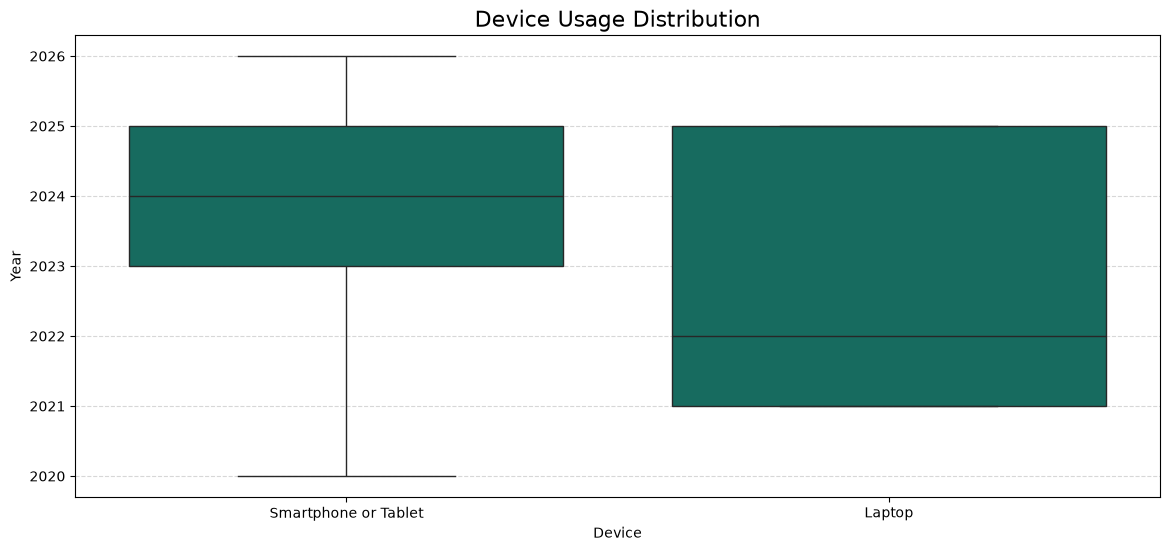

In [14]:
# Define function to simplify the device names
def device(name):
    if "iPhone" in name or "Ipad" in name or "ios" in name:
        return "Smartphone or Tablet"
    else:
        return "Laptop"

# Creating a new column for devices
cleaned_data["device"] = cleaned_data["platform"].apply(device)


# Creating a boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(data= cleaned_data, x= "device", y= "year", color= "#097969")

plt.title("Device Usage Distribution", fontsize= 16)
plt.xlabel("Device")
plt.ylabel("Year")

plt.grid(axis= "y", linestyle= "--", alpha= 0.5)

plt.show()


In [15]:
cleaned_data["device"].value_counts()

device
Smartphone or Tablet    85178
Laptop                   4172
Name: count, dtype: int64

#### Q2: How has my listening volume developed in the past 7.5 years?

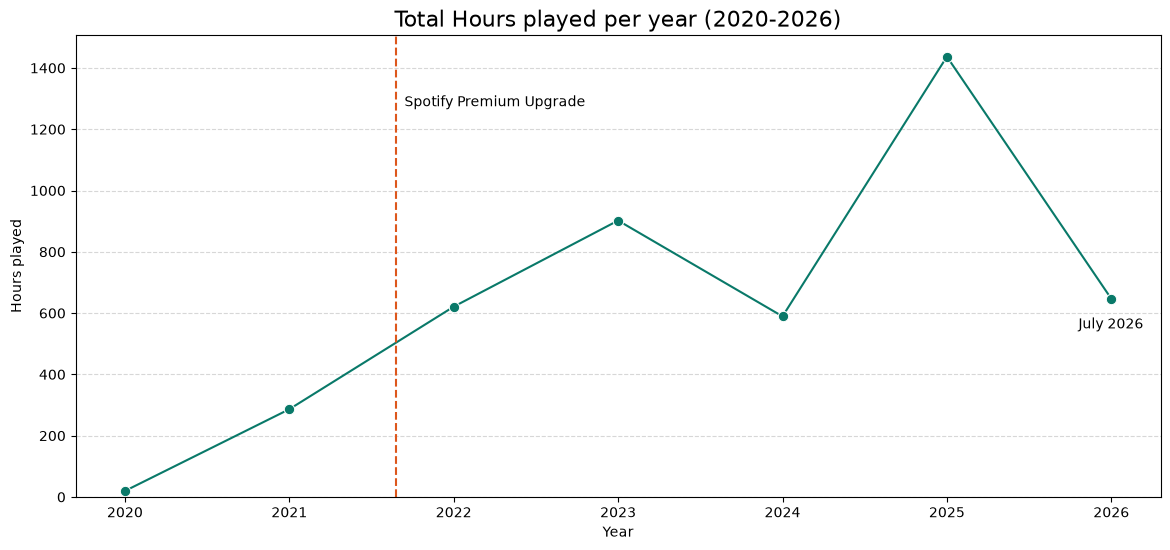

In [16]:
#
yearly_hours = cleaned_data.groupby("year", as_index= False)["minutes_played"].sum()
yearly_hours["hours_played"] = yearly_hours["minutes_played"]/ 60


# Creating a linechart
plt.figure(figsize=(14,6))
sns.lineplot(data= yearly_hours, x= "year", y= "hours_played", color= "#097969", marker= "o", markersize= "7.5", linewidth= "1.5")

plt.title("Total Hours played per year (2020-2026)", fontsize= 16)
plt.xlabel("Year")
plt.axvline(x= 2021.65, color= "#DD571C", linestyle= "--", linewidth= 1.5)
plt.annotate("Spotify Premium Upgrade", xy=(2021.7, 1275))

plt.ylabel("Hours played")
plt.ylim(bottom= 0)
plt.annotate("July 2026", xy=(2025.8, 550))

plt.grid(axis= "y", linestyle= "--", alpha= 0.5)

plt.show()

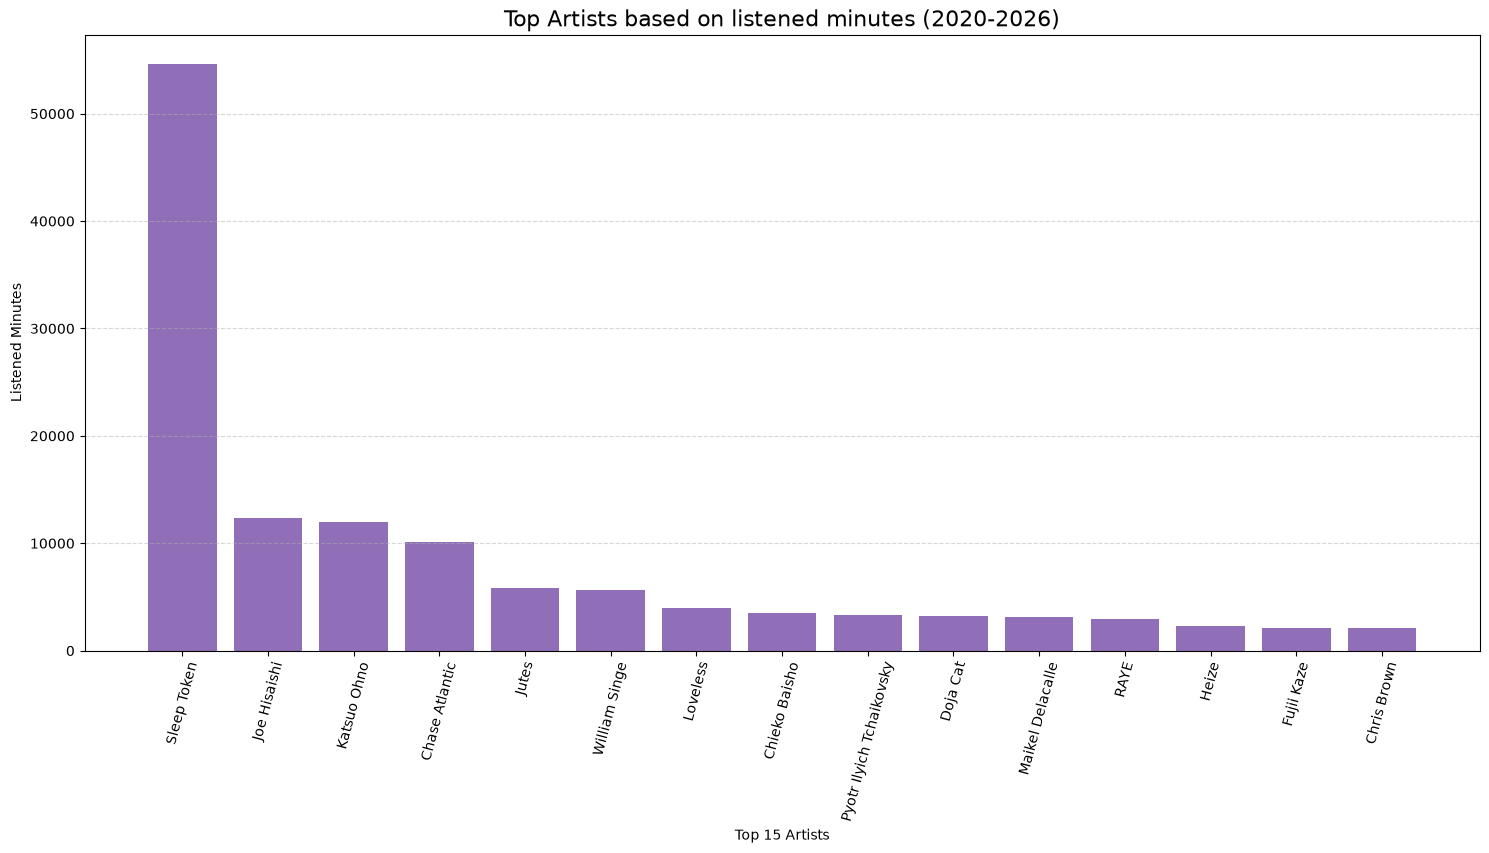

In [17]:
# Aggregate total minutes played per artist and select top 15
top_artists = (cleaned_data.groupby("artist")["minutes_played"].sum().sort_values(ascending= False).head(15))

# Visualise top 15 artists by listened minutes
plt.figure(figsize=(18,8))

plt.bar(x= top_artists.index, height= top_artists.values, color= "#6B3FA0", alpha= 0.75, width= 0.8)

plt.title("Top Artists based on listened minutes (2020-2026)", fontsize= 16)
plt.xlabel("Top 15 Artists")
plt.xticks(rotation= 75)
plt.ylabel("Listened Minutes")

plt.grid(axis= "y", linestyle= "--", alpha= 0.5)
plt.show()

#### Q3: Do major life events (e.g. moving to Vienna, switching majors from Humanities to Data Science) correlate with changes in listening habits and if yes, how has my music taste shifted?

In [18]:
# Define seven selected artists and the first time they were listened to (with timestamps)
ft_sleep_token = cleaned_data[cleaned_data["artist"] == "Sleep Token"]["ts"].min()
ft_jutes = cleaned_data[cleaned_data["artist"] == "Jutes"]["ts"].min()
ft_singe = cleaned_data[cleaned_data["artist"] == "William Singe"]["ts"].min()
ft_tchaikovsky = cleaned_data[cleaned_data["artist"] == "Pyotr Ilyich Tchaikovsky"]["ts"].min()
ft_delacalle = cleaned_data[cleaned_data["artist"] == "Maikel Delacalle"]["ts"].min()
ft_heize = cleaned_data[cleaned_data["artist"] == "Heize"]["ts"].min()
ft_hisaishi = cleaned_data[cleaned_data["artist"] == "Joe Hisaishi"]["ts"].min()

In [19]:
# Create a dictionary which combines artist and the first time they were listened to
artist_data = {
    'Artist': ["Sleep Token", "Jutes", "William Singe", "Pyotr Ilyitch Tchaikovsky", "Maikel Delacalle", "Heize", "Joe Hisaishi"],
    'First listened on': [ft_sleep_token, ft_jutes, ft_singe, ft_tchaikovsky, ft_delacalle, ft_heize, ft_hisaishi]
}

# Creata a data frame
artist_data = pd.DataFrame(artist_data).sort_values(by= "Artist").reset_index(drop= True)
artist_data

,Artist,First listened on
0,Heize,2025-01-01 16:32:27+00:00
1,Joe Hisaishi,2021-01-15 13:50:21+00:00
2,Jutes,2024-07-20 12:00:27+00:00
3,Maikel Delacalle,2021-01-01 13:51:52+00:00
4,Pyotr Ilyitch Tchaikovsky,2021-12-20 18:49:05+00:00
5,Sleep Token,2023-06-18 20:49:08+00:00
6,William Singe,2020-11-05 11:31:30+00:00


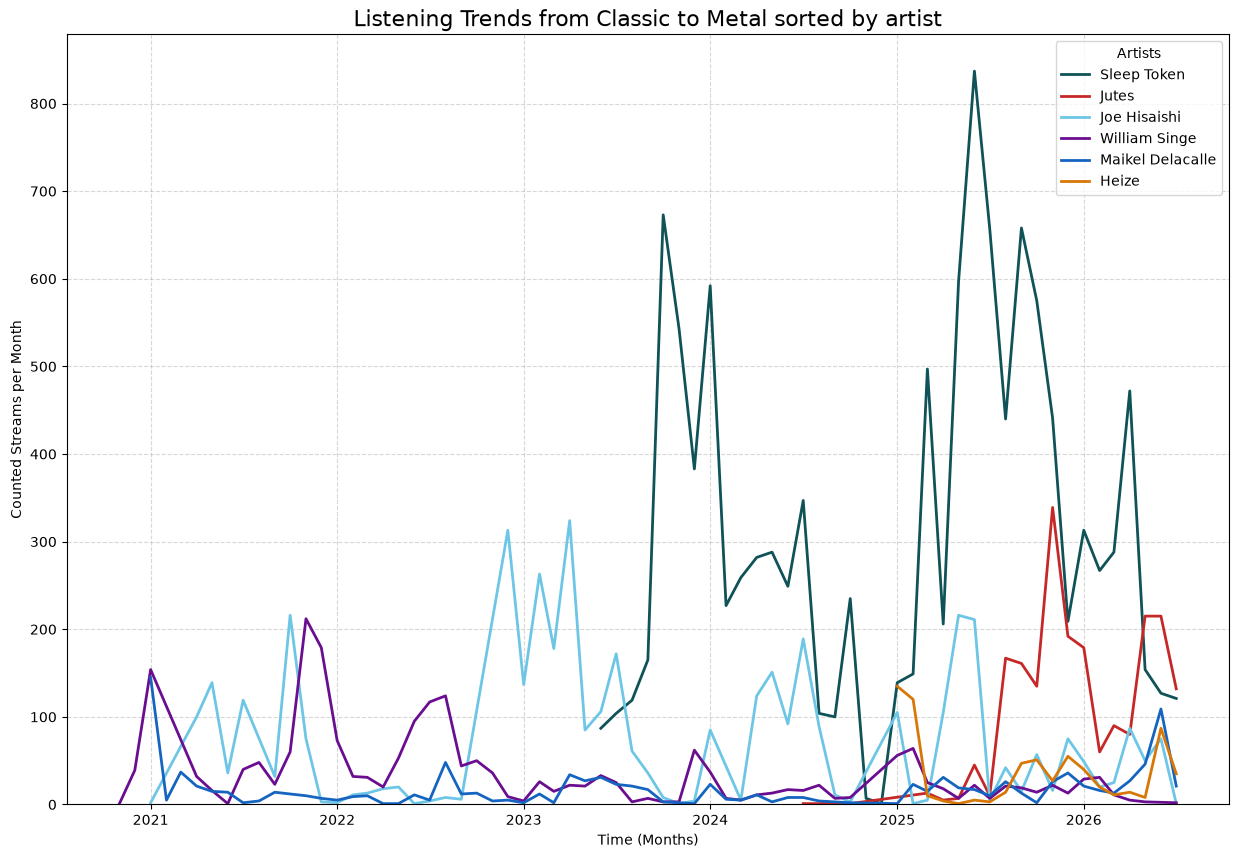

In [20]:
# Select artists and filter them
selected_artists = ["Heize", "Joe Hisaishi", "Jutes", "Maikel Delacalle", "Pyotr Ilyitch Tchaikovsky", "Sleep Token", "William Singe"]
filtered_artists = cleaned_data[cleaned_data["artist"].isin(selected_artists)].copy()


# Determine the timestamps of each song
filtered_artists["month"] = filtered_artists["ts"].dt.tz_localize(None).dt.to_period("M").dt.to_timestamp()

# Determine the number of streams
monthly_streams = filtered_artists.value_counts(["month", "artist"]).reset_index()

# Assign a specific colour to each artist
artist_colours= {
    "Heize": "#D97706",
    "Joe Hisaishi": "#6EC6E6",
    "Jutes": "#C62828",
    "Maikel Delacalle": "#1565C0",
    "Pyotr Ilyitch Tchaikovksy": "#A4774D",
    "Sleep Token": "#0F5257",
    "William Singe": "#6A0D91"

}

# Visualising monthly streaming trends across artists
plt.figure(figsize=(15, 10))
sns.lineplot(data= monthly_streams, x= "month", y= "count", hue= "artist", palette= artist_colours, linewidth= 2)

plt.title("Listening Trends from Classic to Metal sorted by artist", fontsize= 16)
plt.xlabel("Time (Months)")
plt.ylabel("Counted Streams per Month")
plt.ylim(bottom= 0)

plt.legend(title= "Artists")
plt.grid(axis= "x", linestyle= "--", alpha= 0.5)
plt.grid(axis= "y", linestyle= "--", alpha= 0.5)

plt.show()

#### Q4: Are there seasonal genre patterns throughout the year?

In [21]:
# Identify my TOP 100 most listened artists of all time
cleaned_data["artist"].value_counts().head(100)

artist
Sleep Token       11912
Katsuo Ohno        4429
Joe Hisaishi       4402
Chase Atlantic     3048
William Singe      2225
                  ...  
BIGBANG             146
BLACKPINK           146
CRO                 146
Kehlani             143
Justin Bieber       143
Name: count, Length: 100, dtype: int64

In [22]:
# Create lists of specific genres
classic_cinematic = ["Joe Hisaishi", "Katsuo Ohno", "Pyotr Ilyich Tchaikovsky", "London Philharmonic Orchestra", "Chieko Baisho", "main character melodies", "Tommee Profitt"]
international_pop = ["Ariana Grande", "Fujii Kaze", "Glee Cast", "Rihanna", "JVKE", "Lady Gaga", "Kevz", "Bruno Mars", "David Guetta", "Demi Lovato", "Pentatonix", "VoicePlay", "Katy Perry", "Pitbull", "George Michael", "James Arthur", "Kevin & Karla", "Michael Schulte", "Dua Lipa", "Tate McRae", "Nelly Furtado", "Walk off the Earth", "Shayne Orok", "Madonna", "Maluma", "ABBA", "Jason Derulo", "Imagine Dragons", "Miley Cyrus", "CRO", "Justin Bieber"]
jazz_swing = ["RAYE", "Michael Bublé", "Riva Taylor"]
k_pop = ["Heize", "LISA", "JENNIE", "Agust D", "EXO","MC MONG", "KAI", "Crush", "TWICE", "MONSTA X", "Stray Kids", "Jung Kook", "BTS", "NCT 127", "BIGBANG", "BLACKPINK"]
rock_metal_alt = ["Sleep Token", "Chase Atlantic", "Jutes", "Loveless", "Dayseeker", "Rain City Drive", "The Word Alive", "STARSET", "SiM", "Our Last Night", "ONE OK ROCK", "Bad Omens", "Fall Out Boy", "Nevertel", "Linked Horizon"]
rnb_rap = ["William Singe", "Doja Cat", "Maikel Delacalle", "Chris Brown", "Timbaland", "The Weeknd", "Chris Grey", "GIMS", "Justin Timberlake", "Empire Cast", "Devvon Terrell", "MEMBA", "T-Pain", "Jay Sean", "Nicki Minaj", "Flo Rida", "Chlöe", "Ty Dolla $ign", "Ciara", "Connor Price", "Cardi B", "Lloyd", "Luniz", "August Alsina", "Yellow Claw", "Lucky Daye", "Amaarae", "Kehlani"]

In [23]:
# Create a dictionary
assign_genre = {}

for artist in classic_cinematic: assign_genre[artist] = "Classic/ Cinematic"
for artist in international_pop: assign_genre[artist] = "International Pop"
for artist in jazz_swing: assign_genre[artist] = "Jazz/ Swing"
for artist in k_pop: assign_genre[artist] = "K-Pop"
for artist in rock_metal_alt: assign_genre[artist] = "Rock/ Metal/ Alternative"
for artist in rnb_rap: assign_genre[artist] = "RnB/ Rap"

# .map() function
cleaned_data["genre"] = cleaned_data["artist"].map(assign_genre). fillna("Other")

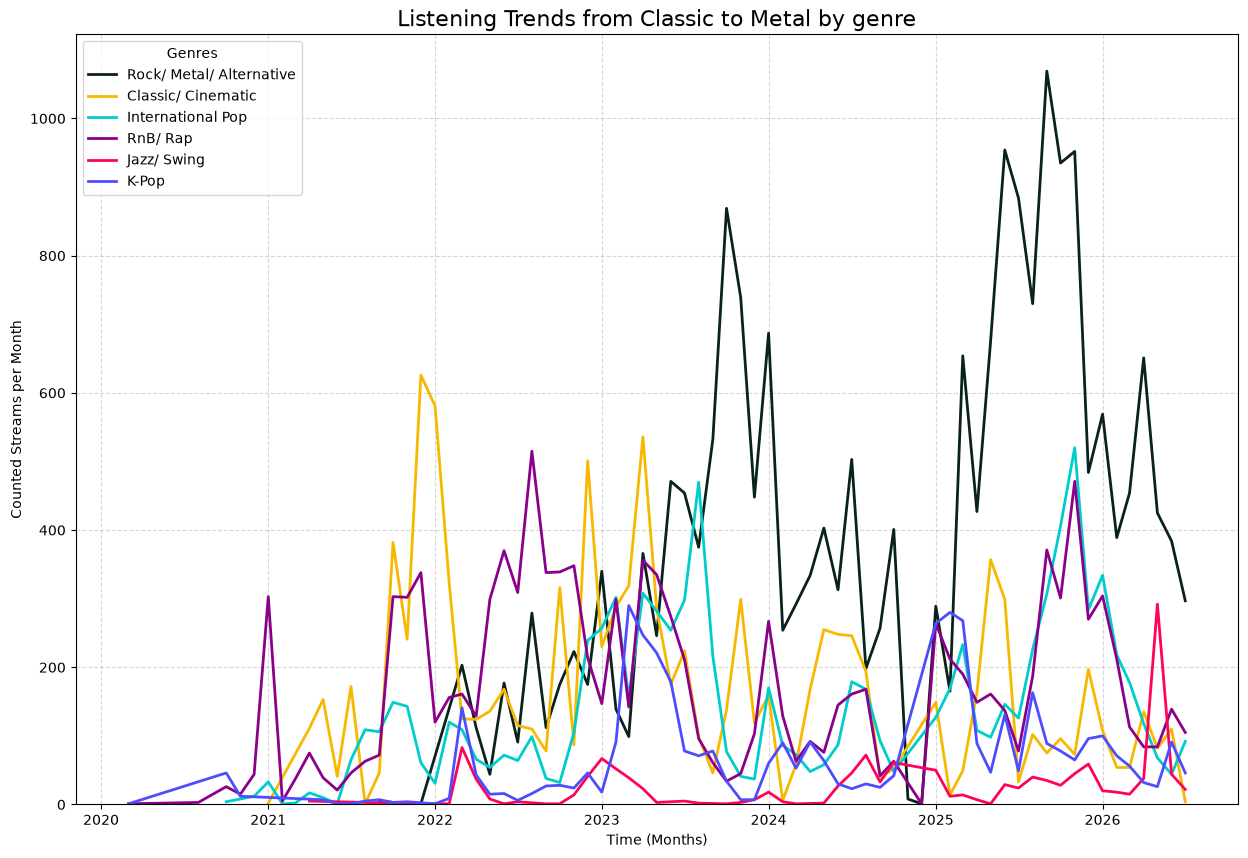

In [24]:
# Select genres and filter them
selected_genres = ["Classic/ Cinematic", "International Pop", "Jazz/ Swing", "K-Pop", "Rock/ Metal/ Alternative", "RnB/ Rap"]
filtered_genres = cleaned_data[cleaned_data["genre"].isin(selected_genres)].copy()

# Determine the timestamps of each song
filtered_genres["month"] = filtered_genres["ts"].dt.tz_localize(None).dt.to_period("M").dt.to_timestamp()

# Determine the number of streams
genre_streams = filtered_genres.value_counts(["month", "genre"]).reset_index()

# Assign a specific colour to each artist
genre_colours= {
    "Classic/ Cinematic": "#F8B800",
    "International Pop": "#00CCCC",
    "Jazz/ Swing": "#FF035B",
    "K-Pop": "#4D4DFF",
    "Rock/ Metal/ Alternative": "#09221B",
    "RnB/ Rap": "#8B008B"

}

# Visualising monthly streaming trends across genres
plt.figure(figsize=(15, 10))
sns.lineplot(data= genre_streams, x= "month", y= "count", hue= "genre", palette= genre_colours, linewidth= 2)

plt.title("Listening Trends from Classic to Metal by genre", fontsize= 16)
plt.xlabel("Time (Months)")
plt.ylabel("Counted Streams per Month")
plt.ylim(bottom= 0)

plt.legend(title= "Genres")
plt.grid(axis= "x", linestyle= "--", alpha= 0.5)
plt.grid(axis= "y", linestyle= "--", alpha= 0.5)

plt.show()

In [25]:
# Create a Pivot Table
pivot_genre = genre_streams.pivot(columns= "genre", index= "month", values= "count").fillna(0).astype(int)

In [26]:
# Create a correlaton matrix based on the "genre" Pivot Table
corr_matrix = pivot_genre.corr()
corr_matrix

genre,Classic/ Cinematic,International Pop,Jazz/ Swing,K-Pop,RnB/ Rap,Rock/ Metal/ Alternative
genre,,,,,,
Classic/ Cinematic,1.000000,0.180820,0.007631,0.126166,0.346945,0.012530
International Pop,0.180820,1.000000,0.160700,0.460820,0.510469,0.554145
Jazz/ Swing,0.007631,0.160700,1.000000,0.126659,0.022129,0.222503
K-Pop,0.126166,0.460820,0.126659,1.000000,0.267738,0.315967
RnB/ Rap,0.346945,0.510469,0.022129,0.267738,1.000000,0.211195
Rock/ Metal/ Alternative,0.012530,0.554145,0.222503,0.315967,0.211195,1.000000


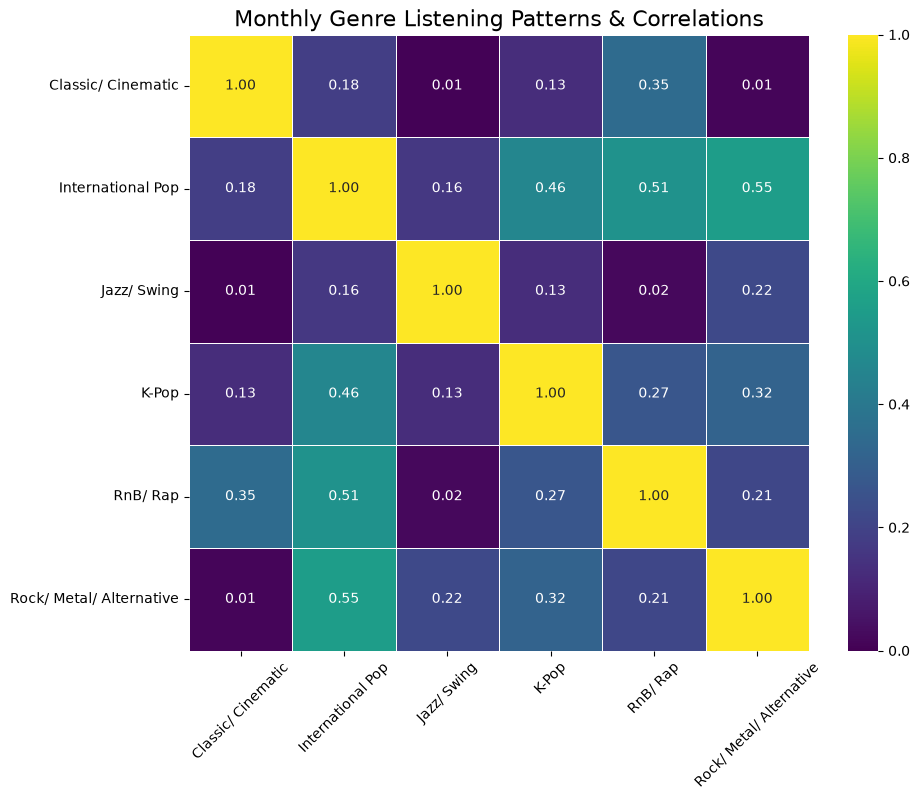

In [27]:
# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data= corr_matrix, vmin= 0, vmax= 1, cmap= "viridis", annot= True, fmt= ".2f", linewidths= 0.5)

plt.title("Monthly Genre Listening Patterns & Correlations", fontsize= 16)
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation = 45)

plt.show()

In [28]:
# Extract hour from timestamp
cleaned_data["hour"] = cleaned_data["ts"].dt.hour

In [29]:
# Create a function
def get_time_of_day(hour):
    if 6 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 14:
        return "Midday"
    elif 14 <= hour < 18:
        return "Afternoon"
    elif 18 <= hour < 22:
        return "Evening"
    else:
        return "Night"

# Apply function
cleaned_data["time_of_day"] = cleaned_data["hour"].apply(get_time_of_day)

In [30]:
# Define the chronological order of a day
order = ["Morning", "Midday", "Afternoon", "Evening", "Night"]

# Convert "time_of_day" to an ordered Categorial data type with chronological order instead of alphabetical sorting
cleaned_data["time_of_day"] = pd.Categorical(cleaned_data["time_of_day"], categories= order, ordered= True)

# Check if the data is sorted chronologically
cleaned_data["time_of_day"].value_counts().sort_index()

time_of_day
Morning      25657
Midday       11671
Afternoon    24313
Evening      20416
Night         7293
Name: count, dtype: int64

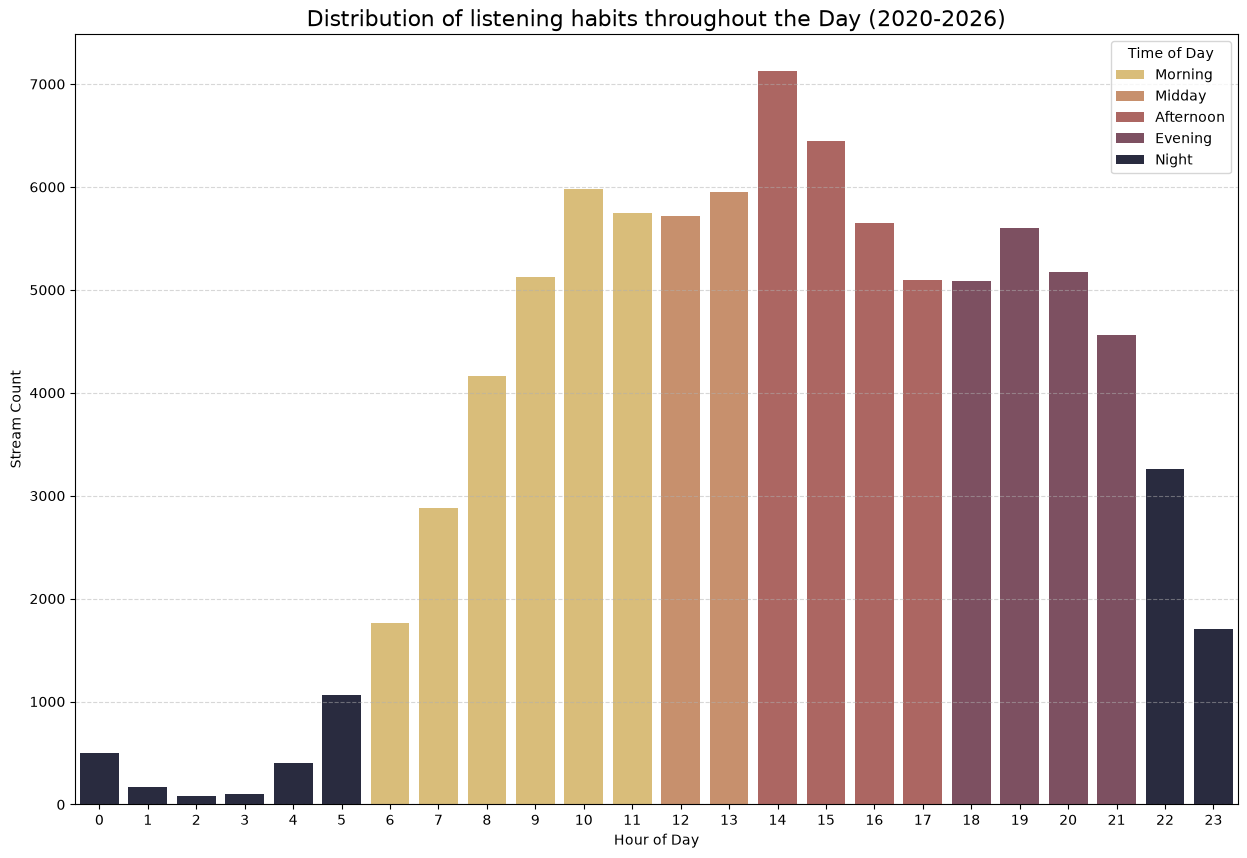

In [31]:
# Create custom palette
custom_day_colours = {
    "Morning": "#E9C46A",
    "Midday": "#D68C5E",
    "Afternoon": "#B85B56",
    "Evening": "#84495F",
    "Night": "#252843"
}

# Visualise listening habits by hours of the Day
plt.figure(figsize= (15, 10))
sns.countplot(data= cleaned_data, 
              x= "hour", 
              hue= "time_of_day", 
              hue_order= ["Morning", "Midday", "Afternoon", "Evening", "Night"], 
              palette= custom_day_colours,
              dodge= False)

plt.title("Distribution of listening habits throughout the Day (2020-2026)", fontsize= 16)
plt.xlabel("Hour of Day")
plt.ylabel("Stream Count")

plt.grid(axis= "y", linestyle= "--", alpha= 0.5)
plt.legend(title= "Time of Day")

plt.show()


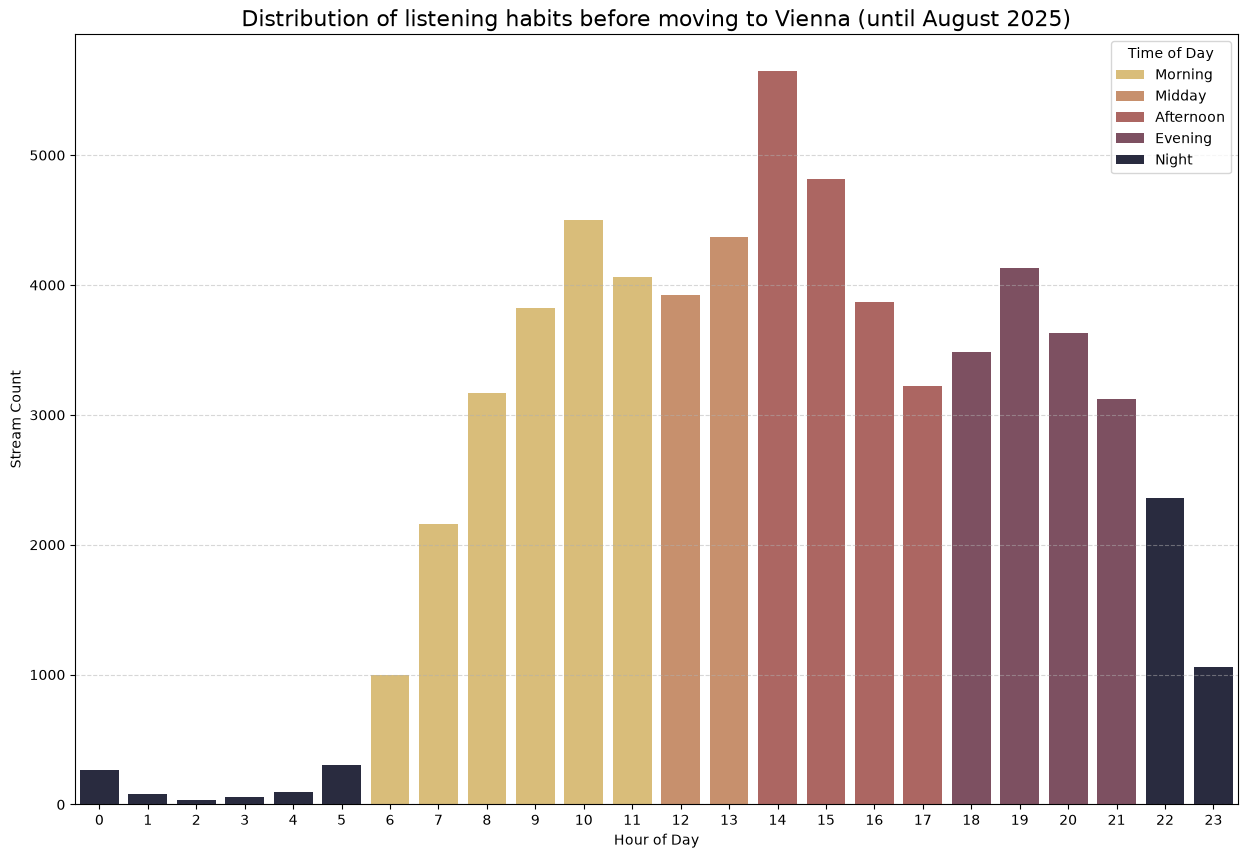

In [32]:
# Filter specific time period
before_moving = cleaned_data[cleaned_data["ts"] < "2025-08-01"]

# Visualise listening habits by hours of day before moving to Vienna
plt.figure(figsize= (15, 10))
sns.countplot(data= before_moving, 
              x= "hour", 
              hue= "time_of_day", 
              hue_order= ["Morning", "Midday", "Afternoon", "Evening", "Night"], 
              palette= custom_day_colours,
              dodge= False, )

plt.title("Distribution of listening habits before moving to Vienna (until August 2025)", fontsize= 16)
plt.xlabel("Hour of Day")
plt.ylabel("Stream Count")
plt.grid(axis= "y", linestyle= "--", alpha= 0.5)
plt.legend(title= "Time of Day")

plt.show()

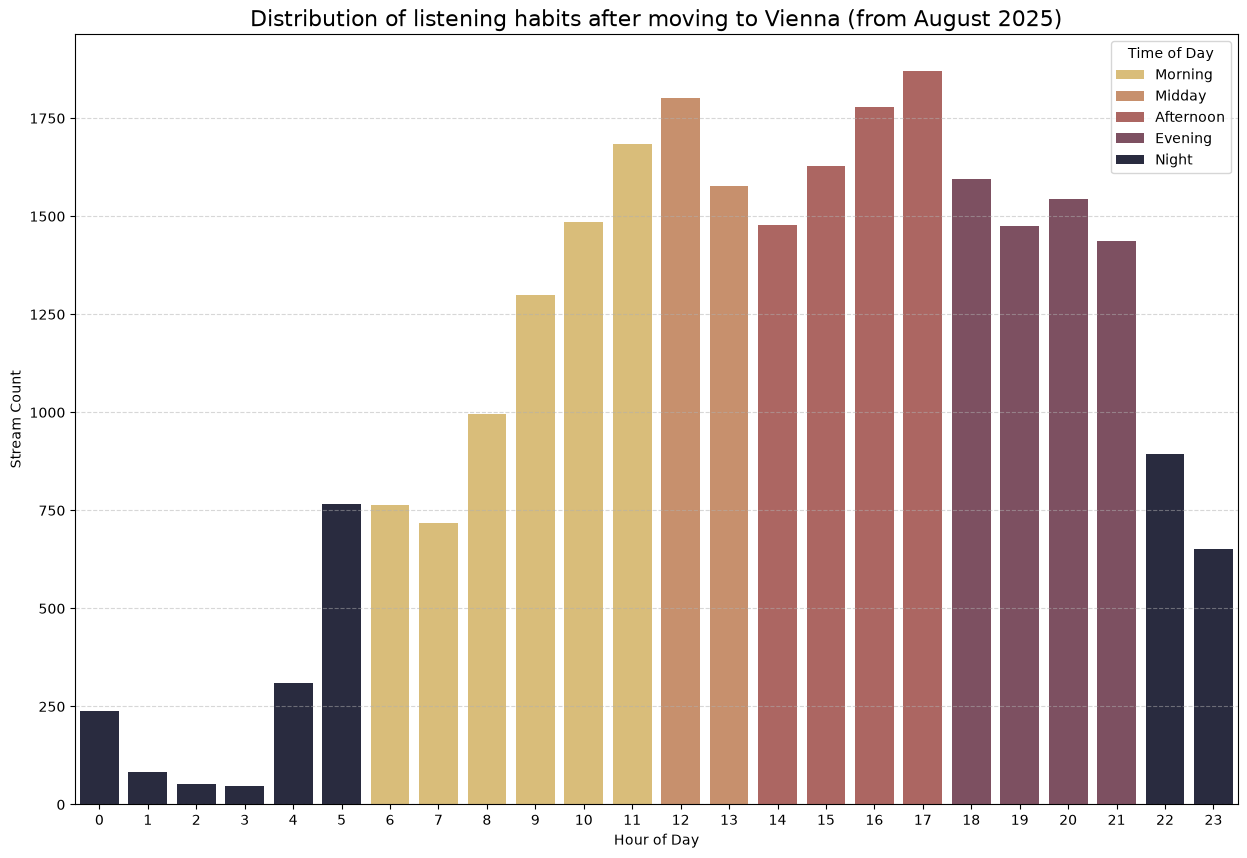

In [33]:
# Filter specific time period
after_moving = cleaned_data[cleaned_data["ts"] >= "2025-08-01"]

# Visualise listening habits by hours of the Day after moving to Vienna
plt.figure(figsize= (15, 10))
sns.countplot(data= after_moving, 
              x= "hour", 
              hue= "time_of_day", 
              hue_order= ["Morning", "Midday", "Afternoon", "Evening", "Night"], 
              palette= custom_day_colours,
              dodge= False, )

plt.title("Distribution of listening habits after moving to Vienna (from August 2025)", fontsize= 16)
plt.xlabel("Hour of Day")
plt.ylabel("Stream Count")
plt.grid(axis= "y", linestyle= "--", alpha= 0.5)
plt.legend(title= "Time of Day")

plt.show()

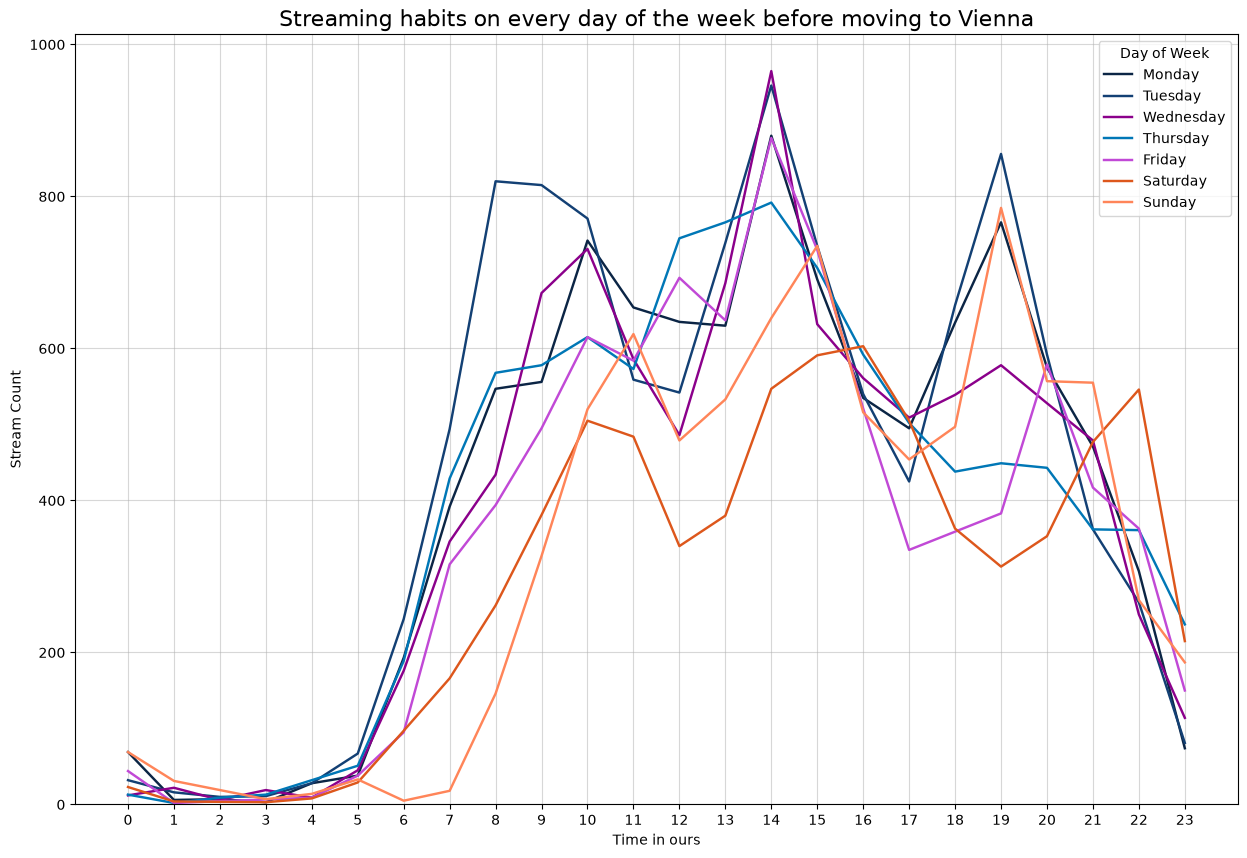

In [34]:
# Extract the name of the weekday from "ts"
cleaned_data["day_name"] = cleaned_data["ts"].dt.day_name()

# Filter data for the period before moving to Vienna
counts_after = cleaned_data[cleaned_data["ts"] < "2025-08-01"].groupby(["day_name", "hour"]).size().reset_index(name= "count")

# Create a palette
day_colour = {
    "Monday": "#0B2545",
    "Tuesday": "#134074",
    "Wednesday": "#8B008B",
    "Thursday": "#0077B6",

    "Friday": "#C149D6",
    "Saturday": "#DD571C",
    "Sunday": "#FF8559"
}

# Create a specific order
days_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Visualise the streaming habits on every day of the week before moving to Vienna
plt.figure(figsize= (15, 10))
sns.lineplot(data= counts_after, x= "hour",y= "count", hue= "day_name", hue_order= days_order, palette= day_colour, linewidth= 1.75)

plt.title("Streaming habits on every day of the week before moving to Vienna", fontsize= 16)
plt.xlabel("Time in ours")
plt.xticks(range(0, 24))
plt.ylabel("Stream Count")
plt.ylim(bottom= 0)

plt.grid(axis= "x", alpha= 0.5)
plt.grid(axis= "y", alpha= 0.5)
plt.legend(title= "Day of Week")

plt.show()

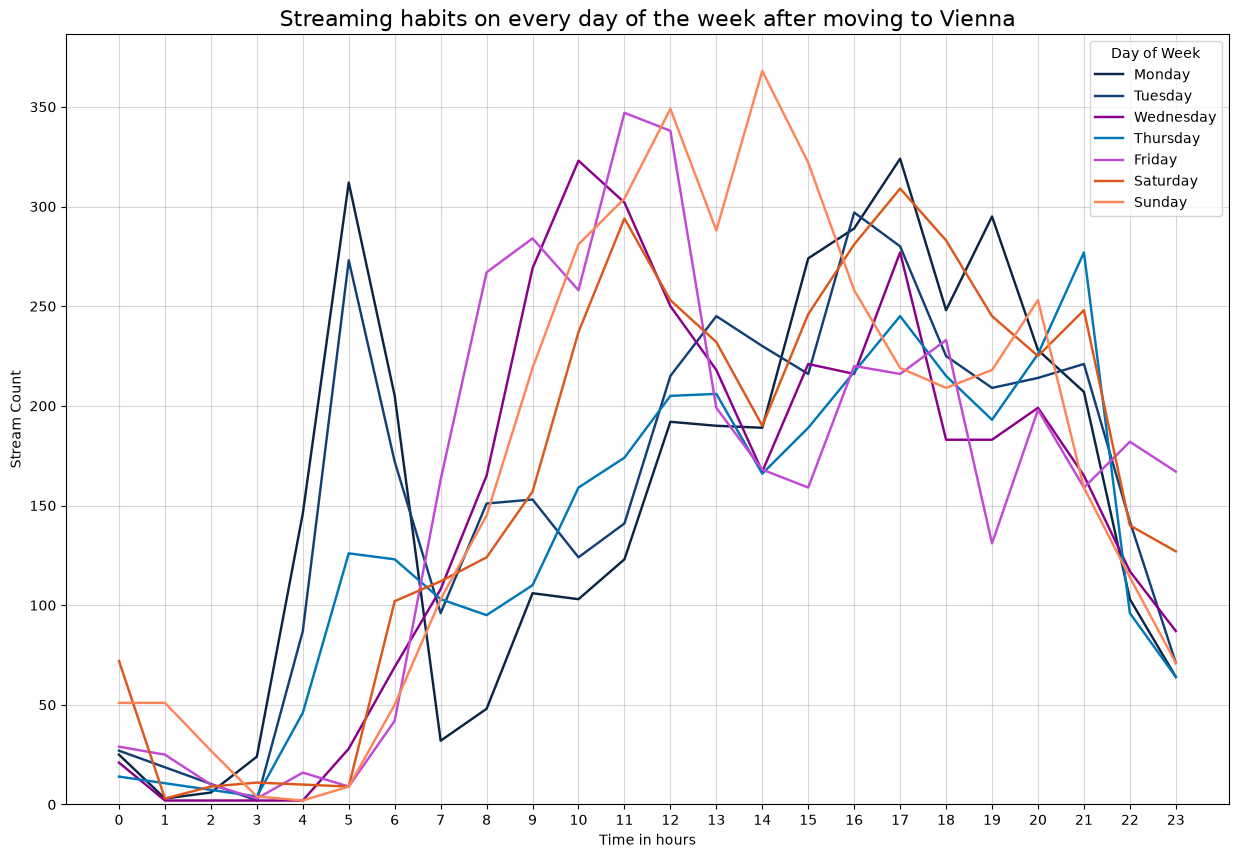

In [35]:
# Filter data for the period after moving to Vienna
counts_after = cleaned_data[cleaned_data["ts"] >= "2025-08-01"].groupby(["day_name", "hour"]).size().reset_index(name= "count")

# Create a palette
day_colour = {
    "Monday": "#0B2545",
    "Tuesday": "#134074",
    "Wednesday": "#8B008B",
    "Thursday": "#0077B6",
    "Friday": "#C149D6",
    "Saturday": "#DD571C",
    "Sunday": "#FF8559"
}

# Creat a specific order
days_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Visualise the streaming habits on every day after moving to Vienna
plt.figure(figsize= (15, 10))
sns.lineplot(data= counts_after, x= "hour",y= "count", hue= "day_name", hue_order= days_order, palette= day_colour, linewidth= 1.75)

plt.title("Streaming habits on every day of the week after moving to Vienna", fontsize= 16)
plt.xlabel("Time in hours")
plt.xticks(range(0, 24))
plt.ylabel("Stream Count")
plt.ylim(bottom= 0)

plt.grid(axis= "x", alpha= 0.5)
plt.grid(axis= "y", alpha= 0.5)
plt.legend(title= "Day of Week")

plt.show()

In [36]:
# Extract weekdays
cleaned_data["day_type"] = np.where(cleaned_data["ts"].dt.dayofweek >= 5, "Weekend", "Weekday")

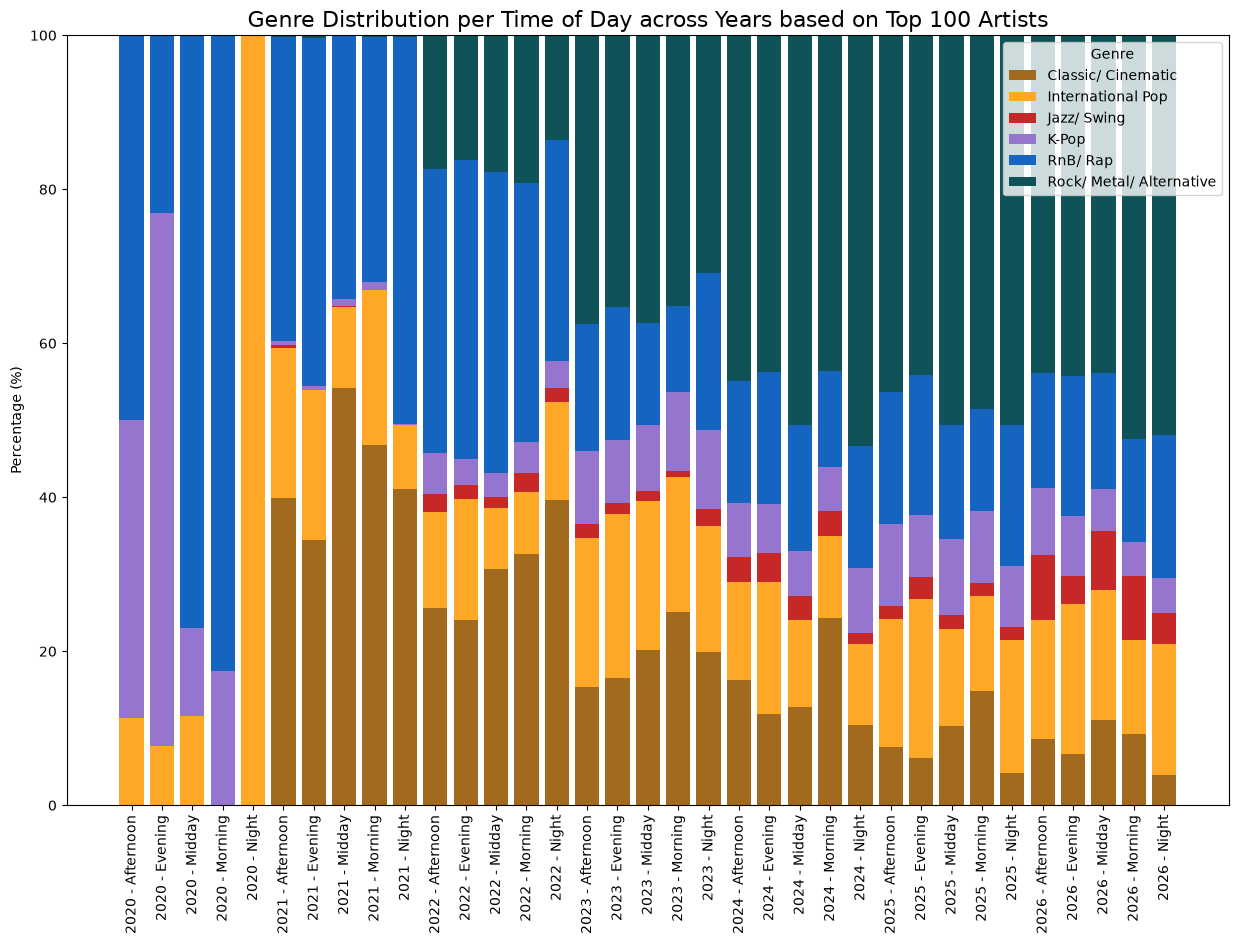

In [37]:
# Apply function "get_day_of_day" to "filtered_genres"
filtered_genres["time_of_day"] = cleaned_data["hour"].apply(get_time_of_day)

# Normalise streams per daytime by genre
daytime_genre = filtered_genres.groupby(["year", "time_of_day", "genre"]).size().reset_index(name= "count")
daytime_genre["percent"] = daytime_genre.groupby(["year","time_of_day"]) ["count"].transform(lambda x: (x/ x.sum()) *100)


# Create pivot table
pivot_daytime_genre = daytime_genre.pivot_table(
    index= ["year", "time_of_day"],
    columns= "genre",
    values= "percent",
    fill_value= 0
)

# Determine the colours for the plot
new_genre_colours= {
    "Classic/ Cinematic": "#A26A1E",
    "International Pop": "#FFA726",
    "Jazz/ Swing": "#C62828",
    "K-Pop": "#9575CD",
    "Rock/ Metal/ Alternative": "#0F5257",
    "RnB/ Rap": "#1565C0"
}

# Create a plot
plt.figure(figsize= (15, 10))

# Define a starting point for the bars
bottom_values = 0

# Transform multi index into text labels
x_labels = [f"{year} - {time}" for year, time in pivot_daytime_genre.index]

for genre in pivot_daytime_genre.columns:
    plt.bar(x= x_labels, height= pivot_daytime_genre[genre], bottom= bottom_values, label= genre, color= new_genre_colours.get(genre))
    bottom_values += pivot_daytime_genre[genre]

# Visualise listened genre by daytime using a stacked bar chart
plt.title("Genre Distribution per Time of Day across Years based on Top 100 Artists", fontsize= 16)
plt.xlabel("")
plt.xticks(rotation= 90)
plt.ylabel("Percentage (%)")

plt.legend(title= "Genre")
plt.show()

#### Q5: Can study sessions be identified in the data (e.g. songs on repeat, specific artist I like to listen to while studying)?

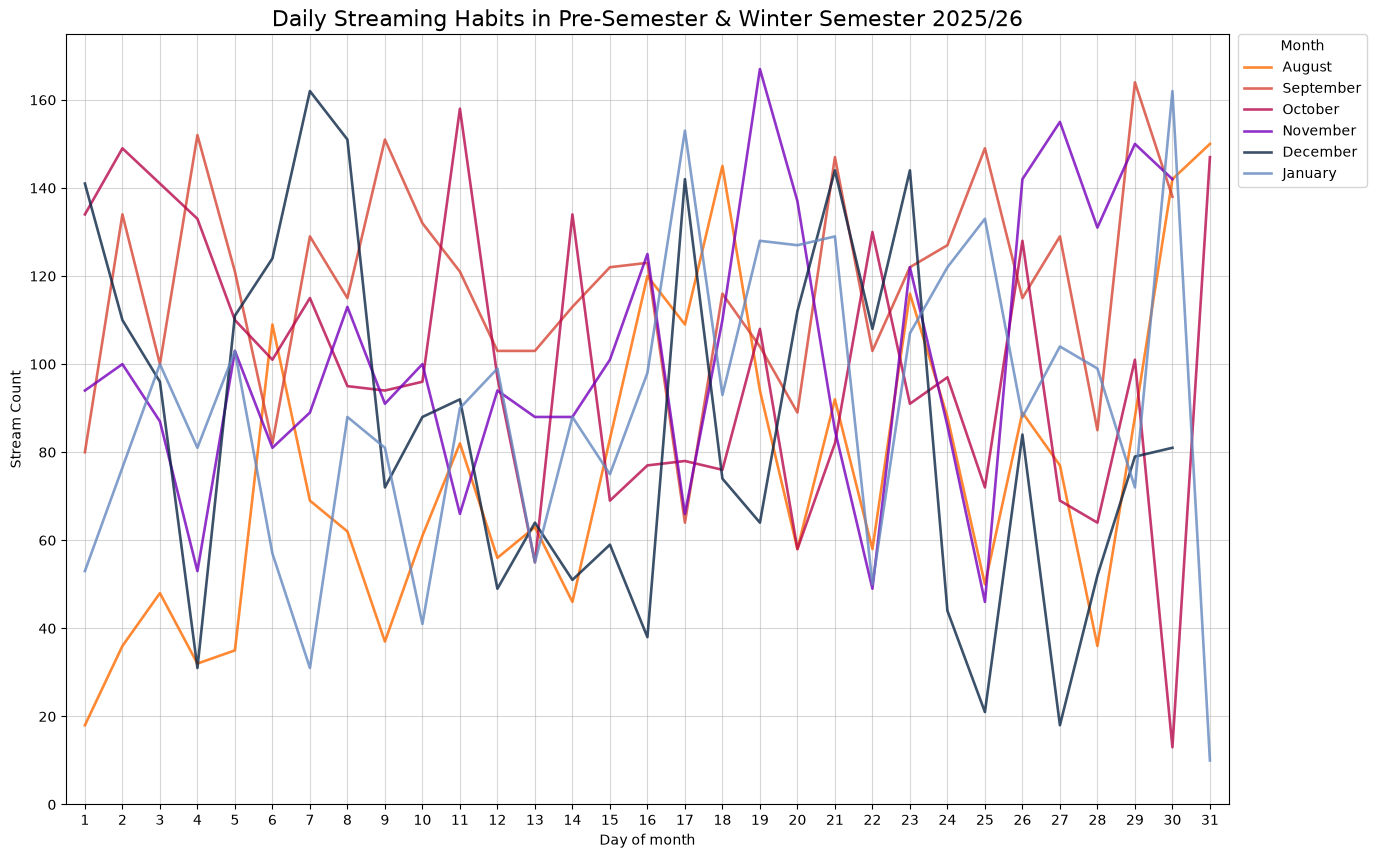

In [38]:
# Extract the name of the month, as well as the day of the month from "ts"
cleaned_data["month_name"] = cleaned_data["ts"].dt.strftime("%B")
cleaned_data["day_of_month"] = cleaned_data["ts"].dt.day

# Filter data for the period after moving to Vienna
counts_months = cleaned_data[(cleaned_data["ts"] >= "2025-08-01") & (cleaned_data["ts"] 
< "2026-02-01")].groupby(["month_name", "day_of_month"]).size().reset_index(name= "count")

# Creat a specific order
months_order = [
    "August",
    "September",
    "October",
    "November",
    "December",
    "January"
]

# Create a palette
winter_colours = {
    "August": "#FF6A00",
    "September": "#D64535",
    "October": "#B7094C",
    "November": "#7600BC",
    "December": "#0B2545",
    "January": "#6487BF"
}

# Visualise the streaming habits on every day after moving to Vienna
plt.figure(figsize= (15, 10))
sns.lineplot(data= counts_months, x= "day_of_month",y= "count", hue= "month_name", hue_order= months_order, 
             palette= winter_colours, linewidth= 1.9, alpha= 0.8)

plt.title("Daily Streaming Habits in Pre-Semester & Winter Semester 2025/26", fontsize= 16)

plt.xlabel("Day of month")
plt.xticks(range(1, 32))
plt.xlim(0.5, 31.5)

plt.ylabel("Stream Count")
plt.ylim(bottom= 0)

plt.grid(axis= "x", alpha= 0.5)
plt.grid(axis= "y", alpha= 0.5)

plt.legend(title= "Month", bbox_to_anchor = (1.125, 1.01), loc= "upper right")

plt.show()

In [39]:
# Create a palette
winter_colours = {
    "August": "#FFBF00",
    "September": "#DE591C",
    "October": "#B7094C",
    "November": "#7600BC",
    "December": "#0B2545",
    "January": "#6487BF"
}

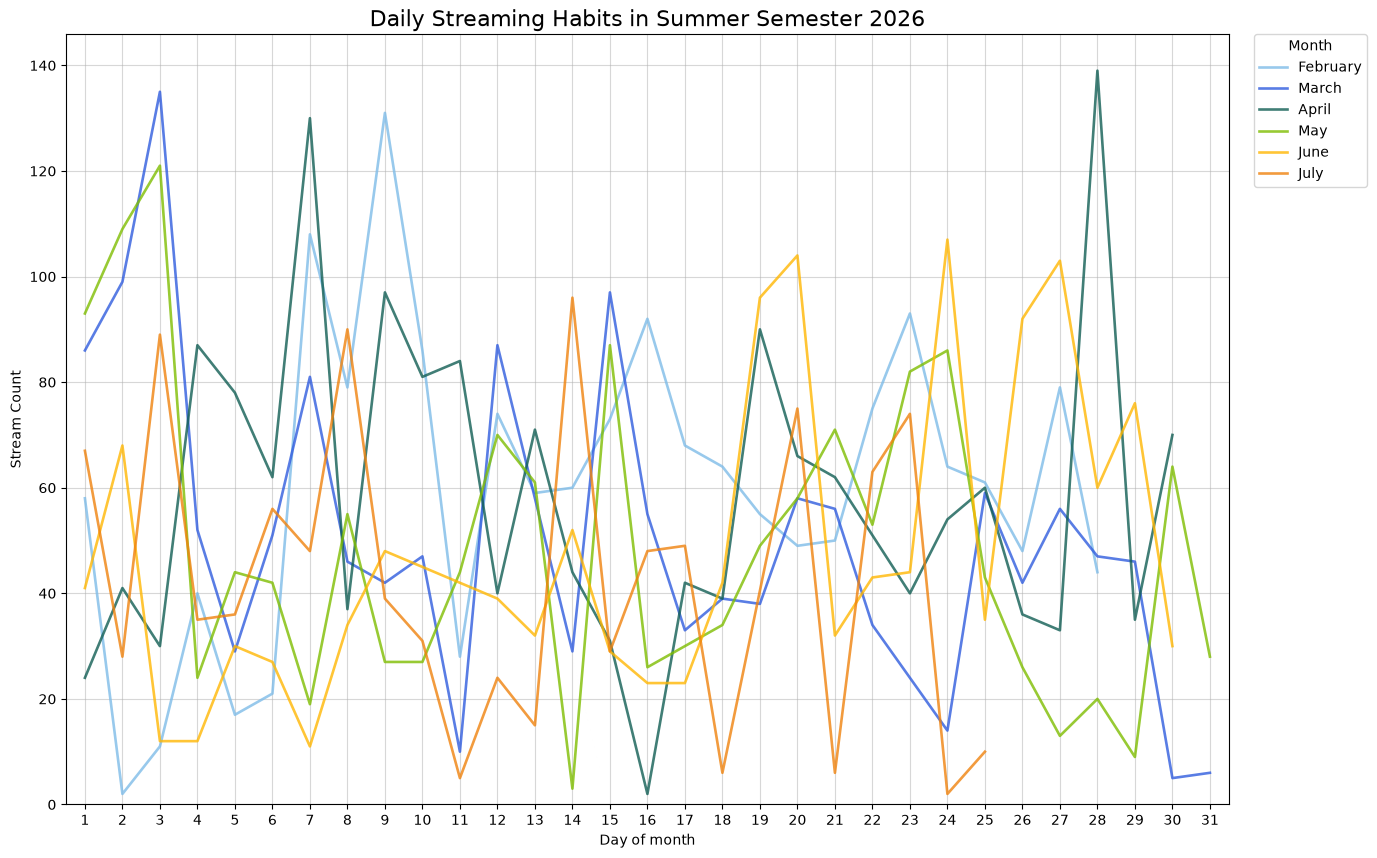

In [40]:
# Extract the name of the month, as well as the day of the month from "ts"
cleaned_data["month_name"] = cleaned_data["ts"].dt.strftime("%B")
cleaned_data["day_of_month"] = cleaned_data["ts"].dt.day

# Filter data for the period after moving to Vienna
counts_months = cleaned_data[cleaned_data["ts"] >= "2026-02-01"].groupby(["month_name", "day_of_month"]).size().reset_index(name= "count")

# Creat a specific order
months_order = [
    "February",
    "March",
    "April",
    "May",
    "June",
    "July"
]

# Create a palette
summer_colours = {
    "February": "#7EBCE8",
    "March": "#305CDE",
    "April": "#115E54",
    "May": "#7EBD01",
    "June": "#FFB703",
    "July": "#EF820D"
}

# Visualise the streaming habits on every day after moving to Vienna
plt.figure(figsize= (15, 10))
sns.lineplot(data= counts_months, x= "day_of_month",y= "count", hue= "month_name", hue_order= months_order, 
             palette= summer_colours, linewidth= 1.9, alpha = 0.8)

plt.title("Daily Streaming Habits in Summer Semester 2026", fontsize= 16)

plt.xlabel("Day of month")
plt.xticks(range(1, 32))
plt.xlim(0.5, 31.5)

plt.ylabel("Stream Count")
plt.ylim(bottom= 0)

plt.grid(axis= "x", alpha= 0.5)
plt.grid(axis= "y", alpha= 0.5)

plt.legend(title= "Month", bbox_to_anchor = (1.125, 1.01), loc= "upper right")

plt.show()

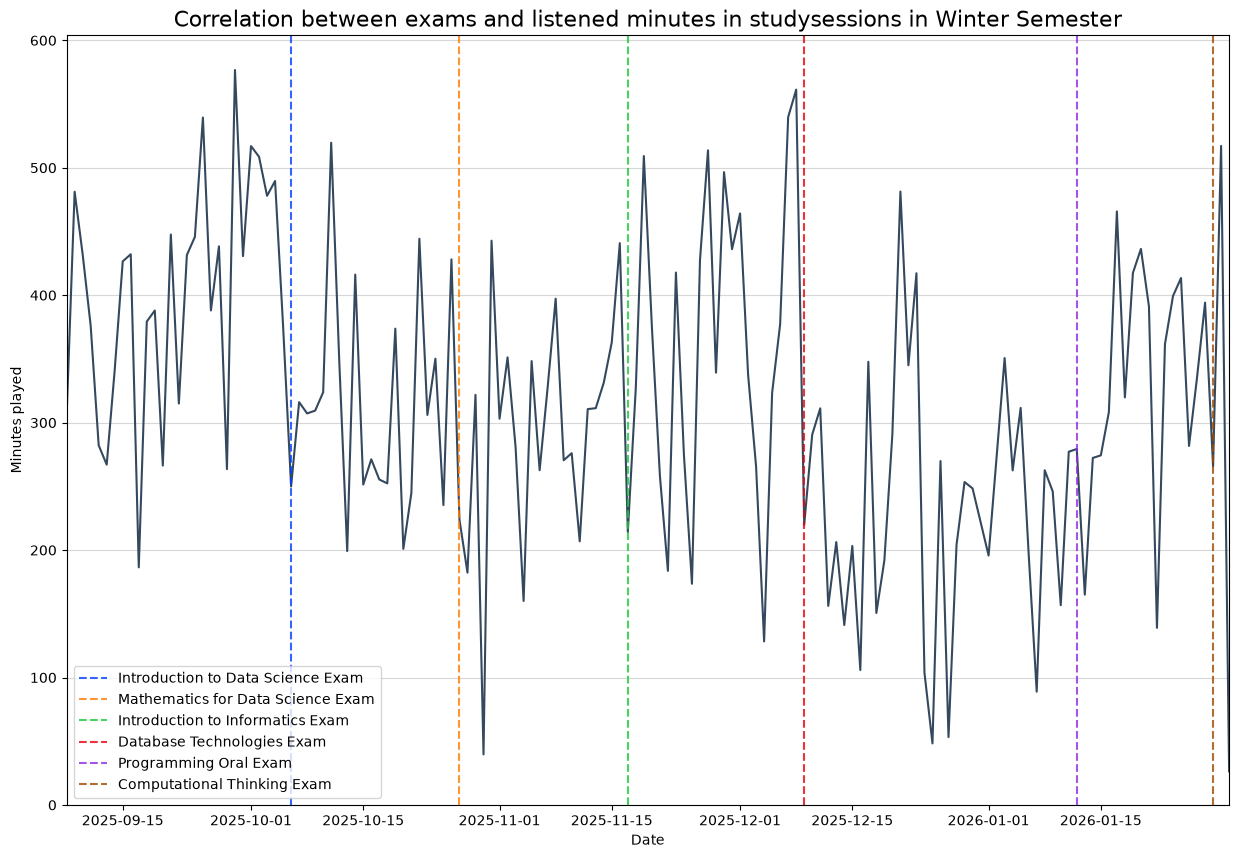

In [83]:
#
cleaned_data["month"] = cleaned_data["ts"].dt.month_name()

# Filter Winter Semester 2026
sose_data = cleaned_data[(cleaned_data["ts"] >= "2025-09-08") & (cleaned_data["ts"] < "2026-02-01")].groupby(cleaned_data["ts"].dt.date)["minutes_played"].sum().reset_index()

#
sose_data["ts"] = pd.to_datetime(sose_data["ts"])

#
sose_exams ={
    "2025-10-06": "Introduction to Data Science Exam",
    "2025-10-27": "Mathematics for Data Science Exam",
    "2025-11-17": "Introduction to Informatics Exam",
    "2025-12-09": "Database Technologies Exam",
    "2026-01-12": "Programming Oral Exam",
    "2026-01-29": "Computational Thinking Exam"
}

palette= sns.color_palette("bright", n_colors=len(sose_exams))

# Visualise the streaming habits on every day after moving to Vienna
plt.figure(figsize= (15, 10))
sns.lineplot(data= sose_data , x= "ts", y= "minutes_played", color= "#34495E", linewidth= 1.5)

plt.title("Correlation between exams and listened minutes in studysessions in Winter Semester", fontsize= 16)

plt.xlabel("Date")
plt.xlim(sose_data["ts"].min(), sose_data["ts"].max())
plt.ylabel("Minutes played")
plt.ylim(bottom= 0)

# Annotate the plot and adding exam dates
for i, (exam_day, exam_name) in enumerate(sose_exams.items()):
    plt.axvline(x= pd.to_datetime(exam_day), color= palette[i], linestyle= "--", linewidth= 1.5, label= exam_name, alpha= 0.8)


plt.legend()
plt.grid(axis= "y", alpha= 0.5)

plt.show()

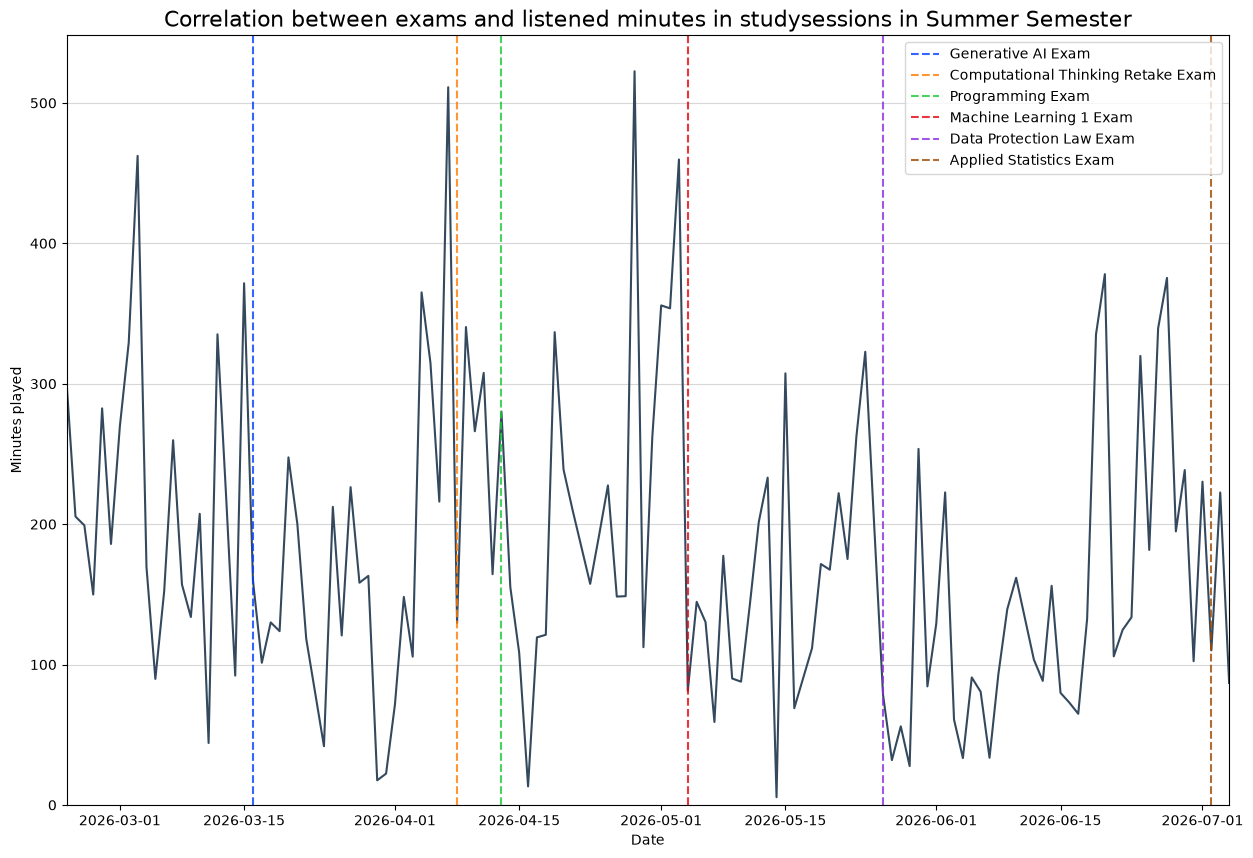

In [78]:
#
cleaned_data["month"] = cleaned_data["ts"].dt.month_name()

# Filter Summer Semester 2026
sose_data = cleaned_data[(cleaned_data["ts"] >= "2026-02-23") & (cleaned_data["ts"] <= "2026-07-05")].groupby(cleaned_data["ts"].dt.date)["minutes_played"].sum().reset_index()

#
sose_data["ts"] = pd.to_datetime(sose_data["ts"])

#
sose_exams ={
    "2026-03-16": "Generative AI Exam",
    "2026-04-08": "Computational Thinking Retake Exam",
    "2026-04-13": "Programming Exam",
    "2026-05-04": "Machine Learning 1 Exam",
    "2026-05-26": "Data Protection Law Exam",
    "2026-07-02": "Applied Statistics Exam"
}

palette= sns.color_palette("bright", n_colors=len(sose_exams))

# Visualise the streaming habits on every day after moving to Vienna
plt.figure(figsize= (15, 10))
sns.lineplot(data= sose_data , x= "ts", y= "minutes_played", color= "#34495E", linewidth= 1.5)

plt.title("Correlation between exams and listened minutes in studysessions in Summer Semester", fontsize= 16)

plt.xlabel("Date")
plt.xlim(sose_data["ts"].min(), sose_data["ts"].max())
plt.ylabel("Minutes played")
plt.ylim(bottom= 0)

# Annotate the plot and adding exam dates
for i, (exam_day, exam_name) in enumerate(sose_exams.items()):
    plt.axvline(x= pd.to_datetime(exam_day), color= palette[i], linestyle= "--", linewidth= 1.5, label= exam_name, alpha= 0.8)


plt.legend()
plt.grid(axis= "y", alpha= 0.5)

plt.show()